# Loan Default Prediction using PyTorch

## Objective

Build a Multi-Layer Perceptron (MLP) using PyTorch for Loan Default Prediction by converting the cleaned dataset into tensors and training the model using a manual training loop.

# Import Libraries

In [12]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

# Set Random Seed

In [13]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

print("Random Seed Set Successfully!")

Random Seed Set Successfully!


# Load Dataset

In [14]:
df = pd.read_csv("train_ctrUa4K.csv")

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


# Data Cleaning

In [15]:
df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])
df["Married"] = df["Married"].fillna(df["Married"].mode()[0])
df["Dependents"] = df["Dependents"].fillna(df["Dependents"].mode()[0])
df["Self_Employed"] = df["Self_Employed"].fillna(df["Self_Employed"].mode()[0])

df["LoanAmount"] = df["LoanAmount"].fillna(df["LoanAmount"].median())
df["Loan_Amount_Term"] = df["Loan_Amount_Term"].fillna(df["Loan_Amount_Term"].median())
df["Credit_History"] = df["Credit_History"].fillna(df["Credit_History"].mode()[0])

df.drop("Loan_ID", axis=1, inplace=True)

# Encode Categorical Features

In [16]:
encoder = LabelEncoder()

categorical_columns = [
    "Gender",
    "Married",
    "Dependents",
    "Education",
    "Self_Employed",
    "Property_Area",
    "Loan_Status"
]

for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])

# Split Dataset

In [17]:
X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Balance Training Data using SMOTE

In [18]:
smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

print(X_train.shape)
print(y_train.shape)

(674, 11)
(674,)


# Convert Data into PyTorch Tensors

In [19]:
X_train = torch.FloatTensor(X_train.values)
X_test = torch.FloatTensor(X_test.values)

y_train = torch.LongTensor(y_train.values)
y_test = torch.LongTensor(y_test.values)

print(X_train.shape)
print(y_train.shape)

torch.Size([674, 11])
torch.Size([674])


C:\Users\HEC\AppData\Local\Temp\ipykernel_11240\3431909480.py:4: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  y_train = torch.LongTensor(y_train.values)


# Build Multi-Layer Perceptron (MLP)

In [20]:
class LoanMLP(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(X_train.shape[1], 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 2)
        )

    def forward(self, x):
        return self.network(x)


model = LoanMLP()

print(model)

LoanMLP(
  (network): Sequential(
    (0): Linear(in_features=11, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=2, bias=True)
  )
)


# Create TensorDataset and DataLoader

In [21]:
from torch.utils.data import TensorDataset, DataLoader


In [22]:
train_dataset = TensorDataset(X_train, y_train)

val_dataset = TensorDataset(X_test, y_test)

In [27]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False
)

In [28]:
print("Training batches:", len(train_loader))

print("Validation batches:", len(val_loader))

Training batches: 11
Validation batches: 2


# Define Loss Function and Optimizer

In [29]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

# Train the Model using Mini-Batches

In [30]:
epochs = 25

train_losses = []
val_losses = []

In [31]:
for epoch in range(epochs):

    model.train()

    running_train_loss = 0.0

    for inputs, labels in train_loader:

        optimizer.zero_grad()

        outputs = model(inputs)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_train_loss += loss.item()

    average_train_loss = running_train_loss / len(train_loader)

    train_losses.append(average_train_loss)

    model.eval()

    running_val_loss = 0.0

    with torch.no_grad():

        for inputs, labels in val_loader:

            outputs = model(inputs)

            loss = criterion(outputs, labels)

            running_val_loss += loss.item()

    average_val_loss = running_val_loss / len(val_loader)

    val_losses.append(average_val_loss)

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Train Loss: {average_train_loss:.4f} | "
        f"Validation Loss: {average_val_loss:.4f}"
    )

Epoch 1/25 | Train Loss: 5.0762 | Validation Loss: 3.4064
Epoch 2/25 | Train Loss: 2.7936 | Validation Loss: 2.4513
Epoch 3/25 | Train Loss: 2.0943 | Validation Loss: 1.7943
Epoch 4/25 | Train Loss: 1.5728 | Validation Loss: 1.2964
Epoch 5/25 | Train Loss: 1.4264 | Validation Loss: 1.0964
Epoch 6/25 | Train Loss: 1.4214 | Validation Loss: 1.5149
Epoch 7/25 | Train Loss: 1.3815 | Validation Loss: 1.3704
Epoch 8/25 | Train Loss: 1.1112 | Validation Loss: 1.1121
Epoch 9/25 | Train Loss: 1.4080 | Validation Loss: 1.2166
Epoch 10/25 | Train Loss: 1.3632 | Validation Loss: 1.1817
Epoch 11/25 | Train Loss: 1.0612 | Validation Loss: 0.9276
Epoch 12/25 | Train Loss: 0.9987 | Validation Loss: 0.9574
Epoch 13/25 | Train Loss: 1.0007 | Validation Loss: 1.0811
Epoch 14/25 | Train Loss: 1.0138 | Validation Loss: 0.9029
Epoch 15/25 | Train Loss: 0.9470 | Validation Loss: 0.8566
Epoch 16/25 | Train Loss: 0.8396 | Validation Loss: 0.9586
Epoch 17/25 | Train Loss: 0.9711 | Validation Loss: 0.9149
Epoch 

# Training and Validation Loss

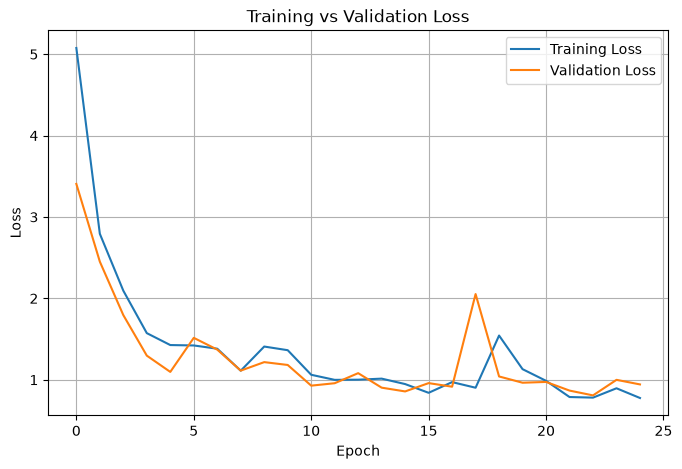

In [32]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

# Model Evaluation

In [33]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for inputs, labels in val_loader:

        outputs = model(inputs)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Validation Accuracy: {accuracy:.2f}%")

Validation Accuracy: 41.46%


# Conclusion

The PyTorch MLP model was successfully upgraded using TensorDataset and DataLoader for mini-batch training. The Adam optimizer improved the optimization process, while validation loss tracking helped monitor the model's performance throughout training. The comparison of training and validation loss provides insight into the model's learning behavior and potential overfitting.